In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 1000)

In [2]:
import networkx as nx
from itertools import combinations

In [3]:
df = pd.read_csv('data/dashboardData_v2.csv', low_memory=False)
df

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,Unknown_Race_Ethnicity,White,ByDiscipline,DaysBetweenVisits,Days_Cared_For,READMISSION,Agency_Medicare_Number,Primary_Diagnosis_ICD_10_C_M_Code,Other_Diagnosis_Code_1_ICD_10_C_M,Other_Diagnosis_Code_2_ICD_10_C_M,Other_Diagnosis_Code_3_ICD_10_C_M,Other_Diagnosis_Code_4_ICD_10_C_M,Other_Diagnosis_Code_5_ICD_10_C_M,Weight_in_pounds,Height_in_inches,is_diabetes,is_heart_failure,is_hypertension,is_renal_failure,BMI,BMI_Category,COUNTY_NAME,POP_COU,HOU_COU,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ANY,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_CIVIL_NONINST_POP_POV,ACS_TOT_CIVIL_POP_POV,ACS_TOT_POP_POV
0,GGGGGGG99DXUNNS,2017-11-29,4BGLS,20709,77,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PT,NaN,56,0,679120,I69.354,I69.311,F03.90,I10.,H35.3290,Z91.81,NaN,NaN,0,0,0,0,0,Underweight,Travis,1290188.0,562488.0,1224251.0,94.89,65937.0,5.11,48453,32.074345,22.720897,18.759759,15.975069,10.125310,1.126621,73.554724,43.738517,32.210448,21.982241,5.364069,77.367655,88.875172,6.101690,82.169241,9.295000,0.120241,88.995310,3.084621,3.860310,6.885931,2.473000,0.005034,85.658207,2.725345,5.117103,90.312759,5.603414,68.051034,0.605414,5.587552,26.428103,31.441345,8.488448,20.070172,28.869621,18.399828,6.166552,14.115345,59.224138,9.056379,25.322103,47.800931,17.476414,15.557483,6.956862,2.961000,8.280103,7.701241,6.646034,4.280931,11.512966,3.100828,10.822793,73.126034,12.605586,5.032621,10.705379,19.303103,14.320379,11.069241,2.068966,14.276517,9.661000,9.426172,4223.255172,3299.406897,4225.820690
1,GGGGGGG99GWNzUW,2017-02-08,1AHKS,696175,74,Female,0.0,0.0,1.0,0.0,0.0,NaN,0.0,RN,NaN,314,0,747199,I25.10,I25.83,I50.42,M12.89,M54.30,R26.89,146.0,65.0,0,0,0,0,25,Overweight,Harris,4731145.0,1842683.0,4677507.0,98.87,53638.0,1.13,48201,20.002284,25.887536,11.996951,22.838174,19.185522,1.939011,57.886619,31.882239,36.757860,28.122410,12.653121,68.342320,85.252104,6.312617,78.048615,14.276799,0.141951,85.394164,2.052950,7.455809,12.283121,2.412104,0.018714,74.575108,3.227824,7.685683,86.899218,12.036313,59.834092,0.734829,8.129937,33.536888,38.805908,10.236151,24.519155,26.830728,21.947275,7.247464,21.881277,93.839029,12.250612,28.372572,34.331007,24.776376,24.694119,13.773768,6.257833,9.230647,14.404757,7.291655,4.506214,14.438022,5.353849,14.852644,62.705198,16.818489,6.254451,11.774038,17.916232,18.082023,14.639892,0.612113,17.751070,1

In [6]:
df.columns.tolist()

['Beneficiary_ID',
 'Assessment_Effective_Date',
 'Submitted_HIPPS_Code',
 'Facility_Internal_ID',
 'Age',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'Unknown_Race_Ethnicity',
 'White',
 'ByDiscipline',
 'DaysBetweenVisits',
 'Days_Cared_For',
 'READMISSION',
 'Agency_Medicare_Number',
 'Primary_Diagnosis_ICD_10_C_M_Code',
 'Other_Diagnosis_Code_1_ICD_10_C_M',
 'Other_Diagnosis_Code_2_ICD_10_C_M',
 'Other_Diagnosis_Code_3_ICD_10_C_M',
 'Other_Diagnosis_Code_4_ICD_10_C_M',
 'Other_Diagnosis_Code_5_ICD_10_C_M',
 'Weight_in_pounds',
 'Height_in_inches',
 'is_diabetes',
 'is_heart_failure',
 'is_hypertension',
 'is_renal_failure',
 'BMI',
 'BMI_Category',
 'COUNTY_NAME',
 'POP_COU',
 'HOU_COU',
 'POP_URB',
 'POPPCT_URB',
 'POP_RUR',
 'POPPCT_RUR',
 'COUNTYFIPS',
 'ACS_PCT_BACHELOR_DGR',
 'ACS_PCT_COLLEGE_ASSOCIATE_DGR',
 'ACS_PCT_GRADUATE_DGR',
 'ACS_PCT_HS_GRADUATE',
 'ACS_PCT_LT_HS

In [7]:
# source : https://www.aapc.com/codes/icd-10-codes-range/?srsltid=AfmBOoog5_u_SYP-InM8WmaLmuTMld2ifGbeOfkFiaALHsFRC8vKcko5
icd_ranges = [
    ('A00-B99', 'Certain infectious and parasitic diseases'),
    ('C00-D49', 'Neoplasms'),
    ('D50-D89', 'Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism'),
    ('E00-E89', 'Endocrine, nutritional and metabolic diseases'),
    ('F01-F99', 'Mental, Behavioral and Neurodevelopmental disorders'),
    ('G00-G99', 'Diseases of the nervous system'),
    ('H00-H59', 'Diseases of the eye and adnexa'),
    ('H60-H95', 'Diseases of the ear and mastoid process'),
    ('I00-I99', 'Diseases of the circulatory system'),
    ('J00-J99', 'Diseases of the respiratory system'),
    ('K00-K95', 'Diseases of the digestive system'),
    ('L00-L99', 'Diseases of the skin and subcutaneous tissue'),
    ('M00-M99', 'Diseases of the musculoskeletal system and connective tissue'),
    ('N00-N99', 'Diseases of the genitourinary system'),
    ('O00-O9A', 'Pregnancy, childbirth and the puerperium'),
    ('P00-P96', 'Certain conditions originating in the perinatal period'),
    ('Q00-Q99', 'Congenital malformations, deformations and chromosomal abnormalities'),
    ('R00-R99', 'Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified'),
    ('S00-T88', 'Injury, poisoning and certain other consequences of external causes'),
    ('U00-U85', 'Codes for special purposes'),
    ('V00-Y99', 'External causes of morbidity'),
    ('Z00-Z99', 'Factors influencing health status and contact with health services')
]

icd_df = pd.DataFrame(icd_ranges, columns=['CODE_RANGE', 'ICD_SECTION'])

In [8]:
icd_columns = ['Primary_Diagnosis_ICD_10_C_M_Code',
 'Other_Diagnosis_Code_1_ICD_10_C_M',
 'Other_Diagnosis_Code_2_ICD_10_C_M',
 'Other_Diagnosis_Code_3_ICD_10_C_M',
 'Other_Diagnosis_Code_4_ICD_10_C_M',
 'Other_Diagnosis_Code_5_ICD_10_C_M',]

def get_icd_section_and_range(code):
    if not isinstance(code, str) or len(code) < 3:
        return None, None  # Return None for both section and range if invalid code
    prefix = code[:3]  # Extract the first three characters of the ICD code
    for range_code, section in icd_ranges:
        start, end = range_code.split('-')
        if start <= prefix <= end:
            return section, range_code  # Return both section and range
    return None, None

# Apply the function across all ICD columns
df[['ICD_Section', 'ICD_Range']] = df[icd_columns].apply(
    lambda row: pd.Series({
        'ICD_Section': ', '.join({get_icd_section_and_range(code)[0] for code in row if get_icd_section_and_range(code)[0]}),
        'ICD_Range': ', '.join({get_icd_section_and_range(code)[1] for code in row if get_icd_section_and_range(code)[1]})
    }), axis=1)

# Replace empty values with 'Unknown' (if no section or range is found)
df['ICD_Section'] = df['ICD_Section'].apply(lambda x: x if x else 'Unknown')
df['ICD_Range'] = df['ICD_Range'].apply(lambda x: x if x else 'Unknown')

df

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,Unknown_Race_Ethnicity,White,ByDiscipline,DaysBetweenVisits,Days_Cared_For,READMISSION,Agency_Medicare_Number,Primary_Diagnosis_ICD_10_C_M_Code,Other_Diagnosis_Code_1_ICD_10_C_M,Other_Diagnosis_Code_2_ICD_10_C_M,Other_Diagnosis_Code_3_ICD_10_C_M,Other_Diagnosis_Code_4_ICD_10_C_M,Other_Diagnosis_Code_5_ICD_10_C_M,Weight_in_pounds,Height_in_inches,is_diabetes,is_heart_failure,is_hypertension,is_renal_failure,BMI,BMI_Category,COUNTY_NAME,POP_COU,HOU_COU,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ANY,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_CIVIL_NONINST_POP_POV,ACS_TOT_CIVIL_POP_POV,ACS_TOT_POP_POV,ICD_Section,ICD_Range
0,GGGGGGG99DXUNNS,2017-11-29,4BGLS,20709,77,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PT,NaN,56,0,679120,I69.354,I69.311,F03.90,I10.,H35.3290,Z91.81,NaN,NaN,0,0,0,0,0,Underweight,Travis,1290188.0,562488.0,1224251.0,94.89,65937.0,5.11,48453,32.074345,22.720897,18.759759,15.975069,10.125310,1.126621,73.554724,43.738517,32.210448,21.982241,5.364069,77.367655,88.875172,6.101690,82.169241,9.295000,0.120241,88.995310,3.084621,3.860310,6.885931,2.473000,0.005034,85.658207,2.725345,5.117103,90.312759,5.603414,68.051034,0.605414,5.587552,26.428103,31.441345,8.488448,20.070172,28.869621,18.399828,6.166552,14.115345,59.224138,9.056379,25.322103,47.800931,17.476414,15.557483,6.956862,2.961000,8.280103,7.701241,6.646034,4.280931,11.512966,3.100828,10.822793,73.126034,12.605586,5.032621,10.705379,19.303103,14.320379,11.069241,2.068966,14.276517,9.661000,9.426172,4223.255172,3299.406897,4225.820690,"Diseases of the circulatory system, Mental, Be...","F01-F99, Z00-Z99, I00-I99, H00-H59"
1,GGGGGGG99GWNzUW,2017-02-08,1AHKS,696175,74,Female,0.0,0.0,1.0,0.0,0.0,NaN,0.0,RN,NaN,314,0,747199,I25.10,I25.83,I50.42,M12.89,M54.30,R26.89,146.0,65.0,0,0,0,0,25,Overweight,Harris,4731145.0,1842683.0,4677507.0,98.87,53638.0,1.13,48201,20.002284,25.887536,11.996951,22.838174,19.185522,1.939011,57.886619,31.882239,36.757860,28.122410,12.653121,68.342320,85.252104,6.312617,78.048615,14.276799,0.141951,85.394164,2.052950,7.455809,12.283121,2.412104,0.018714,74.575108,3.227824,7.685683,86.899218,12.036313,59.834092,0.734829,8.129937,33.536888,38.805908,10.236151,24.519155,26.830728,21.947275,7.247464,21.881277,93.839029,12.250612,28.372572,34.331007,24.776376,24.694119,13.773768,6.257833,9.230647,14.404757,7.291655,4.506214,14.4380

In [9]:
df['ICD_Section'] = df['ICD_Section'].apply(lambda x: set(x.split(', ')))
df['ICD_Range'] = df['ICD_Range'].apply(lambda x: set(x.split(', ')))
df

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,Unknown_Race_Ethnicity,White,ByDiscipline,DaysBetweenVisits,Days_Cared_For,READMISSION,Agency_Medicare_Number,Primary_Diagnosis_ICD_10_C_M_Code,Other_Diagnosis_Code_1_ICD_10_C_M,Other_Diagnosis_Code_2_ICD_10_C_M,Other_Diagnosis_Code_3_ICD_10_C_M,Other_Diagnosis_Code_4_ICD_10_C_M,Other_Diagnosis_Code_5_ICD_10_C_M,Weight_in_pounds,Height_in_inches,is_diabetes,is_heart_failure,is_hypertension,is_renal_failure,BMI,BMI_Category,COUNTY_NAME,POP_COU,HOU_COU,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ANY,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_CIVIL_NONINST_POP_POV,ACS_TOT_CIVIL_POP_POV,ACS_TOT_POP_POV,ICD_Section,ICD_Range
0,GGGGGGG99DXUNNS,2017-11-29,4BGLS,20709,77,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PT,NaN,56,0,679120,I69.354,I69.311,F03.90,I10.,H35.3290,Z91.81,NaN,NaN,0,0,0,0,0,Underweight,Travis,1290188.0,562488.0,1224251.0,94.89,65937.0,5.11,48453,32.074345,22.720897,18.759759,15.975069,10.125310,1.126621,73.554724,43.738517,32.210448,21.982241,5.364069,77.367655,88.875172,6.101690,82.169241,9.295000,0.120241,88.995310,3.084621,3.860310,6.885931,2.473000,0.005034,85.658207,2.725345,5.117103,90.312759,5.603414,68.051034,0.605414,5.587552,26.428103,31.441345,8.488448,20.070172,28.869621,18.399828,6.166552,14.115345,59.224138,9.056379,25.322103,47.800931,17.476414,15.557483,6.956862,2.961000,8.280103,7.701241,6.646034,4.280931,11.512966,3.100828,10.822793,73.126034,12.605586,5.032621,10.705379,19.303103,14.320379,11.069241,2.068966,14.276517,9.661000,9.426172,4223.255172,3299.406897,4225.820690,"{Diseases of the eye and adnexa, Diseases of t...","{F01-F99, Z00-Z99, I00-I99, H00-H59}"
1,GGGGGGG99GWNzUW,2017-02-08,1AHKS,696175,74,Female,0.0,0.0,1.0,0.0,0.0,NaN,0.0,RN,NaN,314,0,747199,I25.10,I25.83,I50.42,M12.89,M54.30,R26.89,146.0,65.0,0,0,0,0,25,Overweight,Harris,4731145.0,1842683.0,4677507.0,98.87,53638.0,1.13,48201,20.002284,25.887536,11.996951,22.838174,19.185522,1.939011,57.886619,31.882239,36.757860,28.122410,12.653121,68.342320,85.252104,6.312617,78.048615,14.276799,0.141951,85.394164,2.052950,7.455809,12.283121,2.412104,0.018714,74.575108,3.227824,7.685683,86.899218,12.036313,59.834092,0.734829,8.129937,33.536888,38.805908,10.236151,24.519155,26.830728,21.947275,7.247464,21.881277,93.839029,12.250612,28.372572,34.331007,24.776376,24.694119,13.773768,6.257833,9.230647,14.404757,7.291655,4.506214,14.43

In [10]:
df.columns

Index(['Beneficiary_ID', 'Assessment_Effective_Date', 'Submitted_HIPPS_Code',
       'Facility_Internal_ID', 'Age', 'Gender',
       'American_Indian_or_Alaska_Native', 'Asian',
       'Black_or_African_American', 'Hispanic_or_Latino',
       ...
       'ACS_PCT_POV_MULTI', 'ACS_PCT_POV_NHPI', 'ACS_PCT_POV_OTHER',
       'ACS_PCT_POV_WHITE', 'ACS_PCT_VET_POV_18_64',
       'ACS_TOT_CIVIL_NONINST_POP_POV', 'ACS_TOT_CIVIL_POP_POV',
       'ACS_TOT_POP_POV', 'ICD_Section', 'ICD_Range'],
      dtype='object', length=110)

In [11]:
df.to_csv('data/dashboardData_ICDSections_v2.csv', index=False)

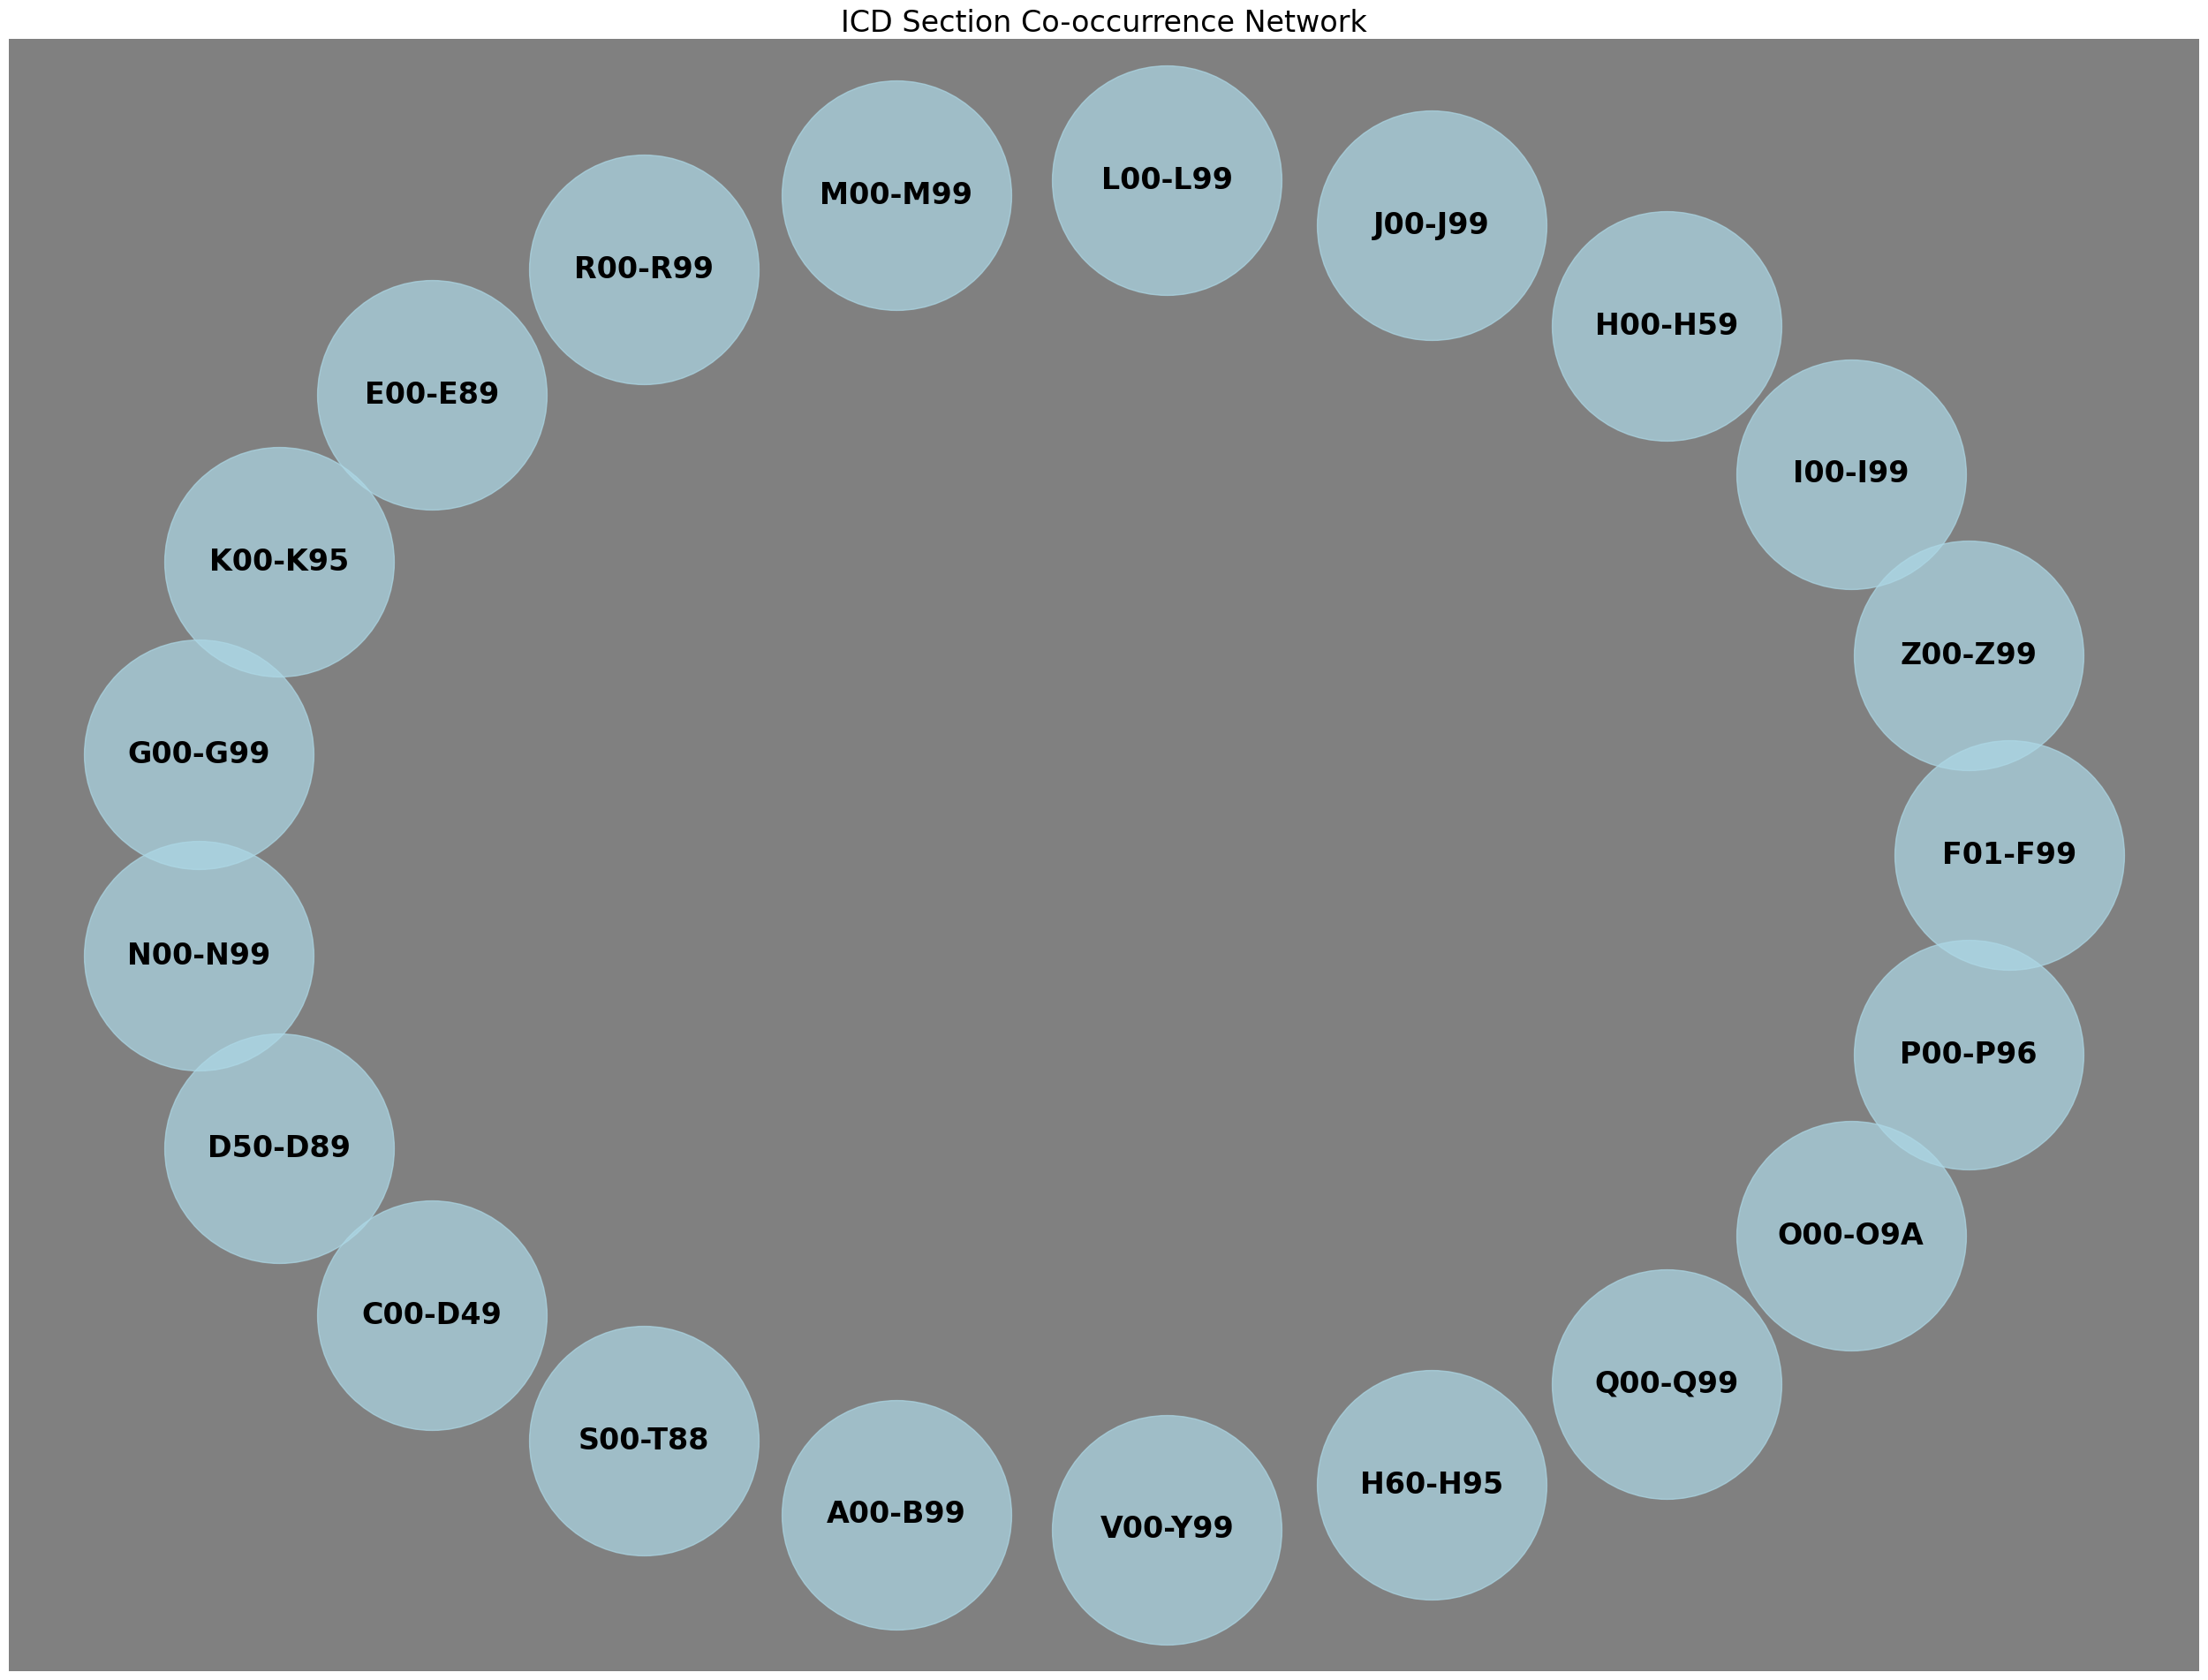

In [12]:
G = nx.Graph()

# Build edges from co-occurring ICD sections
for sections in df['ICD_Range']:
    for combo in combinations(sections, 2):  # Generate section pairs
        if G.has_edge(*combo):
            G[combo[0]][combo[1]]['weight'] += 1  # Increase weight if already exists
        else:
            G.add_edge(*combo, weight=1)  # Add new edge with weight 1

# Filter out edges with weight < 2 (adjust this as necessary)
min_weight = 2
edges_to_keep = [(u, v) for u, v, w in G.edges(data=True) if w['weight'] >= min_weight]

# Create a new graph with only the filtered edges
G_filtered = nx.Graph()
G_filtered.add_edges_from(edges_to_keep)

# Ensure the 'weight' attribute is retained when adding edges
for u, v in G_filtered.edges():
    G_filtered[u][v]['weight'] = G[u][v]['weight']

# Use a different layout (circular_layout or kamada_kawai_layout)
plt.figure(figsize=(32, 24))
pos = nx.circular_layout(G_filtered)  # Or you can try nx.circular_layout(G_filtered)

# Draw nodes and edges
nx.draw_networkx_nodes(G_filtered, pos, node_size=35000, node_color='lightblue', alpha=0.7)
# Draw edges with weight-based width
edge_weights = [G_filtered[u][v]['weight'] for u, v in G_filtered.edges()]
nx.draw_networkx_edges(G_filtered, pos, width=[w / 2 for w in edge_weights], alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G_filtered, pos, font_size=24, font_weight='bold')

# Set the title
plt.title("ICD Section Co-occurrence Network", fontsize=24)
plt.axis('off')  # Hide axes for cleaner view
plt.show()

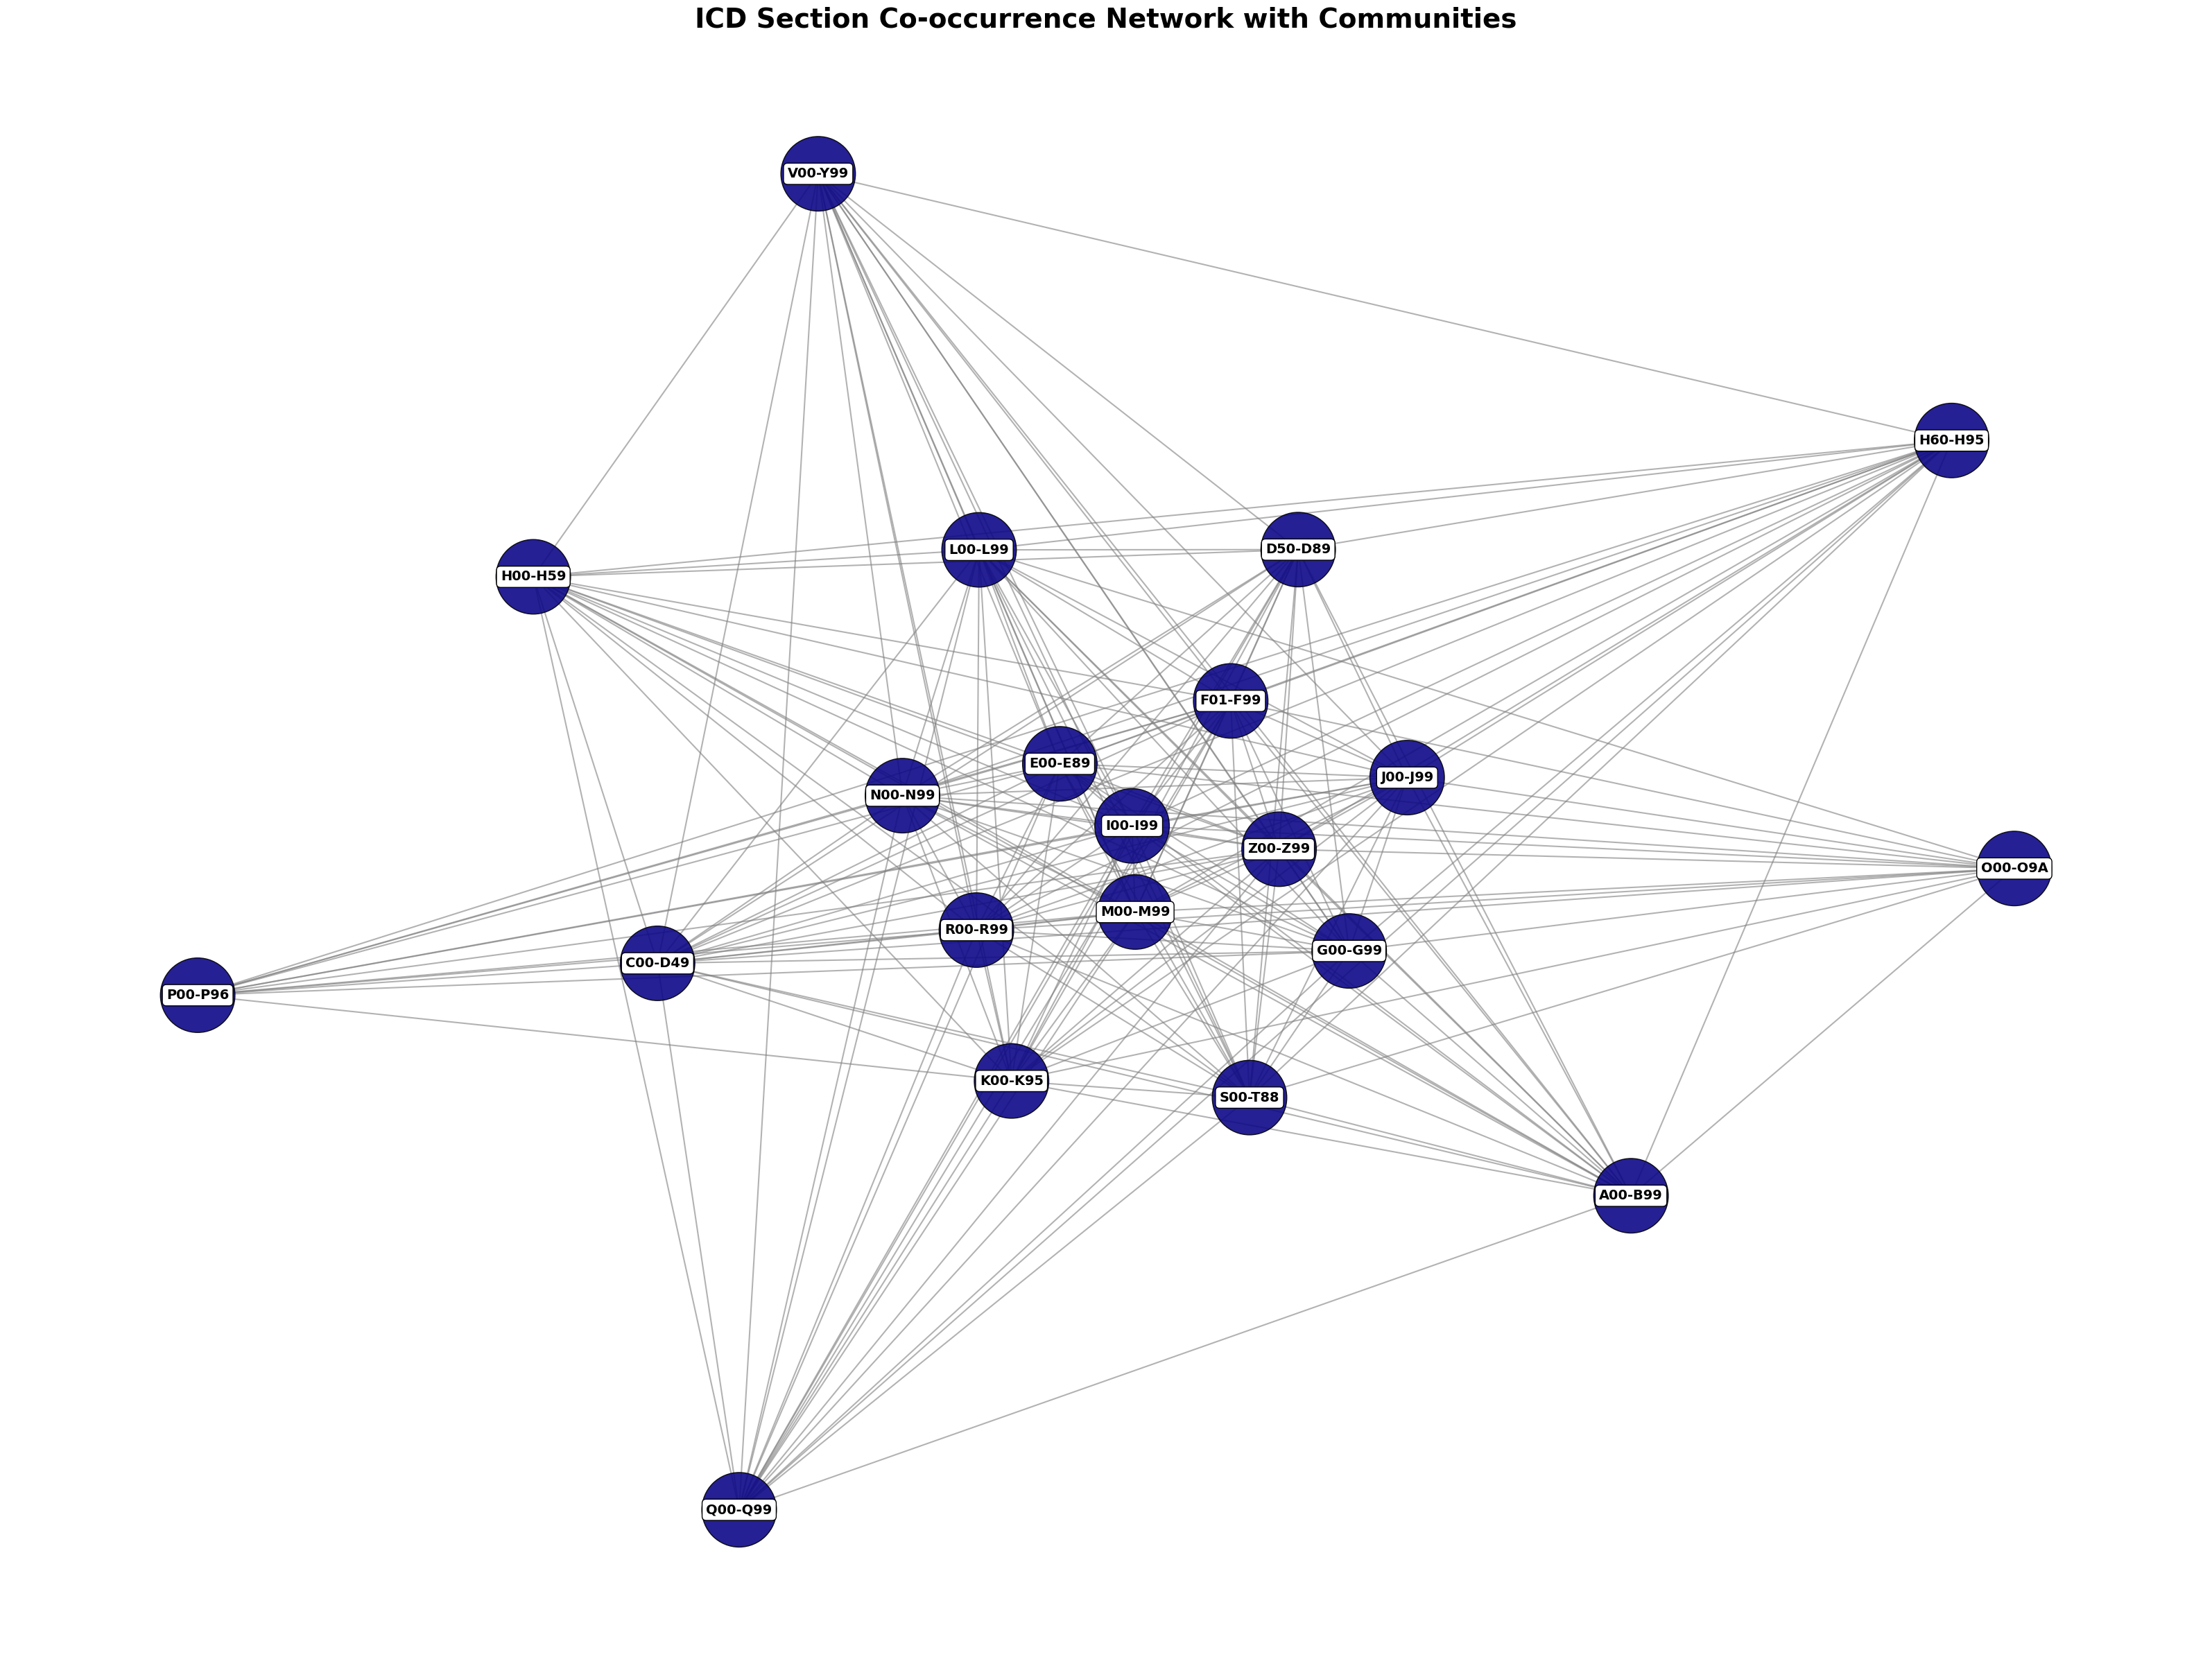

In [13]:
import community as community_louvain
import matplotlib.colors as mcolors
import numpy as np

# Compute the best partition (community detection)
partition = community_louvain.best_partition(G_filtered)

# Set up the layout with improved spacing
plt.figure(figsize=(32, 24))
pos = nx.spring_layout(G_filtered, seed=42, k=30)  # Adjust 'k' for better spacing

# Define a colormap for communities
unique_communities = list(set(partition.values()))
colors = plt.cm.plasma(np.linspace(0, 1, len(unique_communities)))  # High-contrast colormap
community_colors = {comm: colors[i] for i, comm in enumerate(unique_communities)}

# Draw the nodes with community coloring and increased size
node_size = 6000  # Increase node size for visibility
nx.draw_networkx_nodes(
    G_filtered, pos, node_size=node_size, node_color=[community_colors[partition[node]] for node in G_filtered.nodes()], 
    alpha=0.9, edgecolors="black"
)

# Draw the edges with a softer color and better transparency
nx.draw_networkx_edges(G_filtered, pos, width=1.5, alpha=0.6, edge_color='gray')

# Draw the labels with larger font size and outline for readability
font_size = 14
nx.draw_networkx_labels(G_filtered, pos, font_size=font_size, font_weight='bold', 
                        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))

# Title and cleanup
plt.title("ICD Section Co-occurrence Network with Communities", fontsize=28, fontweight="bold")
plt.axis('off')  # Hide axes
plt.tight_layout()
plt.savefig('figures/CoOccurrenceNetworkICDSection.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
def get_icd_section(code):
    for range_code, section in icd_ranges:
        start, end = range_code.split('-')
        if start <= code <= end:
            return section
    return 'Unknown'

In [15]:
diag_columns = [
    'Primary_Diagnosis_ICD_10_C_M_Code',
 'Other_Diagnosis_Code_1_ICD_10_C_M',
 'Other_Diagnosis_Code_2_ICD_10_C_M',
 'Other_Diagnosis_Code_3_ICD_10_C_M',
 'Other_Diagnosis_Code_4_ICD_10_C_M',
 'Other_Diagnosis_Code_5_ICD_10_C_M',
]

melted_df = df.melt(id_vars=['Beneficiary_ID'], value_vars=diag_columns, var_name='Diagnosis_Type', value_name='Diagnosis_Code')

melted_df['READMISSION'] = df['READMISSION']

bene_count_per_code = melted_df.groupby(['Diagnosis_Code', 'READMISSION'])['Beneficiary_ID'].nunique().reset_index()

bene_count_per_code_pivoted = bene_count_per_code.pivot_table(
    index='Diagnosis_Code', columns='READMISSION', values='Beneficiary_ID', aggfunc='sum', fill_value=0
).reset_index()

bene_count_per_code_pivoted.columns = ['Diagnosis_Code', 'Readmission_0_Count', 'Readmission_1_Count']

bene_count_per_code_pivoted['BENE_ID_Count'] = bene_count_per_code_pivoted[['Readmission_0_Count', 'Readmission_1_Count']].sum(axis=1)
bene_count_per_code_pivoted

,Diagnosis_Code,Readmission_0_Count,Readmission_1_Count,BENE_ID_Count
0,A01.03,0,1,1
1,A02.0,2,3,5
2,A02.1,1,2,3
3,A02.22,0,1,1
4,A03.9,1,0,1
...,...,...,...,...
9028,s09.90xd,0,1,1
9029,s72.002d,1,1,2
9030,z82.61,1,0,1
9031,z82.71,1,0,1


In [16]:
bene_count_per_code_pivoted = bene_count_per_code_pivoted.sort_values(by='BENE_ID_Count', ascending=False)
bene_count_per_code_pivoted

,Diagnosis_Code,Readmission_0_Count,Readmission_1_Count,BENE_ID_Count
1933,I10.,17518,2013,19531
8799,Z47.1,11326,974,12300
1936,I11.0,7494,2592,10086
1067,E11.9,6486,846,7332
2793,J44.9,5773,1453,7226
...,...,...,...,...
13,A06.3,0,1,1
14,A06.4,1,0,1
17,A08.32,0,1,1
21,A15.6,0,1,1


In [17]:
bene_count_per_code_pivoted['ICD_SECTION'] = bene_count_per_code_pivoted['Diagnosis_Code'].apply(get_icd_section)
bene_count_per_code_pivoted

,Diagnosis_Code,Readmission_0_Count,Readmission_1_Count,BENE_ID_Count,ICD_SECTION
1933,I10.,17518,2013,19531,Diseases of the circulatory system
8799,Z47.1,11326,974,12300,Factors influencing health status and contact ...
1936,I11.0,7494,2592,10086,Diseases of the circulatory system
1067,E11.9,6486,846,7332,"Endocrine, nutritional and metabolic diseases"
2793,J44.9,5773,1453,7226,Diseases of the respiratory system
...,...,...,...,...,...
13,A06.3,0,1,1,Certain infectious and parasitic diseases
14,A06.4,1,0,1,Certain infectious and parasitic diseases
17,A08.32,0,1,1,Certain infectious and parasitic diseases
21,A15.6,0,1,1,Certain infectious and parasitic diseases


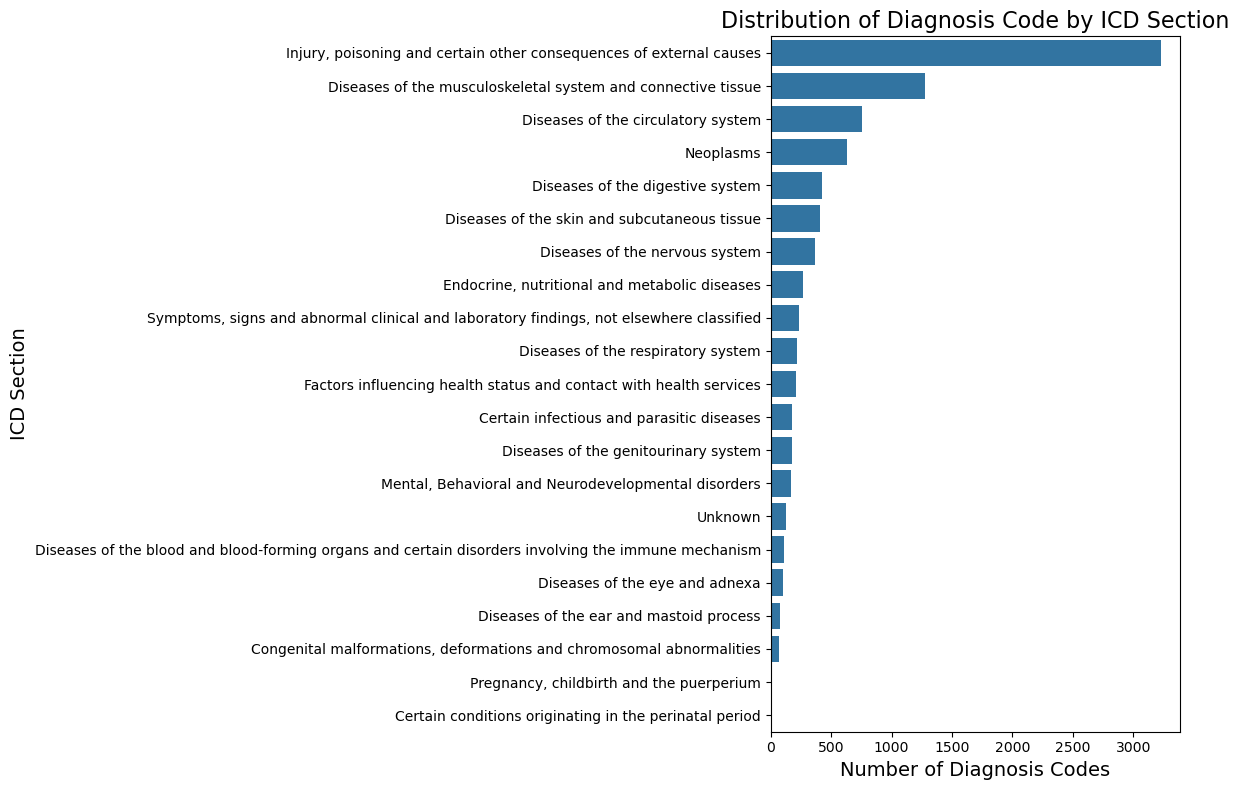

In [19]:
section_counts = bene_count_per_code_pivoted.groupby('ICD_SECTION')['Diagnosis_Code'].count().reset_index()
section_counts = section_counts.sort_values(by='Diagnosis_Code', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Diagnosis_Code', y='ICD_SECTION', data=section_counts)

plt.title('Distribution of Diagnosis Code by ICD Section', fontsize=16)
plt.xlabel('Number of Diagnosis Codes', fontsize=14)
plt.ylabel('ICD Section', fontsize=14)
plt.tight_layout()
plt.savefig('figures/distributionICDSection.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
print('Min: ', bene_count_per_code_pivoted['BENE_ID_Count'].min())
print('Max: ', bene_count_per_code_pivoted['BENE_ID_Count'].max())
print('Avg: ', bene_count_per_code_pivoted['BENE_ID_Count'].mean())



Min:  1
Max:  19531
Avg:  33.538580759437615


In [21]:
bene_count_per_code.to_csv('data/ICD_PatientCount.csv', index=False)

In [23]:
melted_df['Diagnosis_Code_Prefix'] = melted_df['Diagnosis_Code'].str.split('.').str[0]

# Step 2: Group by the extracted prefix and calculate the required stats
grouped_stats = melted_df.groupby('Diagnosis_Code_Prefix').agg(
    BENE_ID_Count=('Beneficiary_ID', 'nunique'),
    Readmission_0_Count=('READMISSION', lambda x: (x == 0).sum()),
    Readmission_1_Count=('READMISSION', lambda x: (x == 1).sum())
).reset_index()

# Optionally, you can add the total count across all rows
total_bene_id_count = grouped_stats['BENE_ID_Count'].sum()
grouped_stats['BENE_ID_Count'] = grouped_stats[['Readmission_0_Count', 'Readmission_1_Count']].sum(axis=1)

grouped_stats

,Diagnosis_Code_Prefix,BENE_ID_Count,Readmission_0_Count,Readmission_1_Count
0,A00,0,0,0
1,A01,1,0,1
2,A02,9,3,6
3,A03,1,1,0
4,A04,410,148,262
...,...,...,...,...
1605,z85,0,0,0
1606,z91,0,0,0
1607,z93,1,1,0
1608,z95,0,0,0


In [24]:
grouped_stats = grouped_stats.sort_values(by='BENE_ID_Count', ascending=False)
grouped_stats

,Diagnosis_Code_Prefix,BENE_ID_Count,Readmission_0_Count,Readmission_1_Count
292,E11,31147,26087,5060
549,I10,19548,17532,2016
1443,Z47,17737,15756,1981
652,J44,15201,10455,4746
550,I11,12446,9594,2852
...,...,...,...,...
1590,r26,0,0,0
1591,r32,0,0,0
1593,r35,0,0,0
1594,r56,0,0,0


In [25]:
grouped_stats['ICD_SECTION'] = grouped_stats['Diagnosis_Code_Prefix'].apply(get_icd_section)
grouped_stats

,Diagnosis_Code_Prefix,BENE_ID_Count,Readmission_0_Count,Readmission_1_Count,ICD_SECTION
292,E11,31147,26087,5060,"Endocrine, nutritional and metabolic diseases"
549,I10,19548,17532,2016,Diseases of the circulatory system
1443,Z47,17737,15756,1981,Factors influencing health status and contact ...
652,J44,15201,10455,4746,Diseases of the respiratory system
550,I11,12446,9594,2852,Diseases of the circulatory system
...,...,...,...,...,...
1590,r26,0,0,0,Unknown
1591,r32,0,0,0,Unknown
1593,r35,0,0,0,Unknown
1594,r56,0,0,0,Unknown


In [26]:
grouped_stats.to_csv('data/ICDPrefix_PatientCount.csv', index=False)

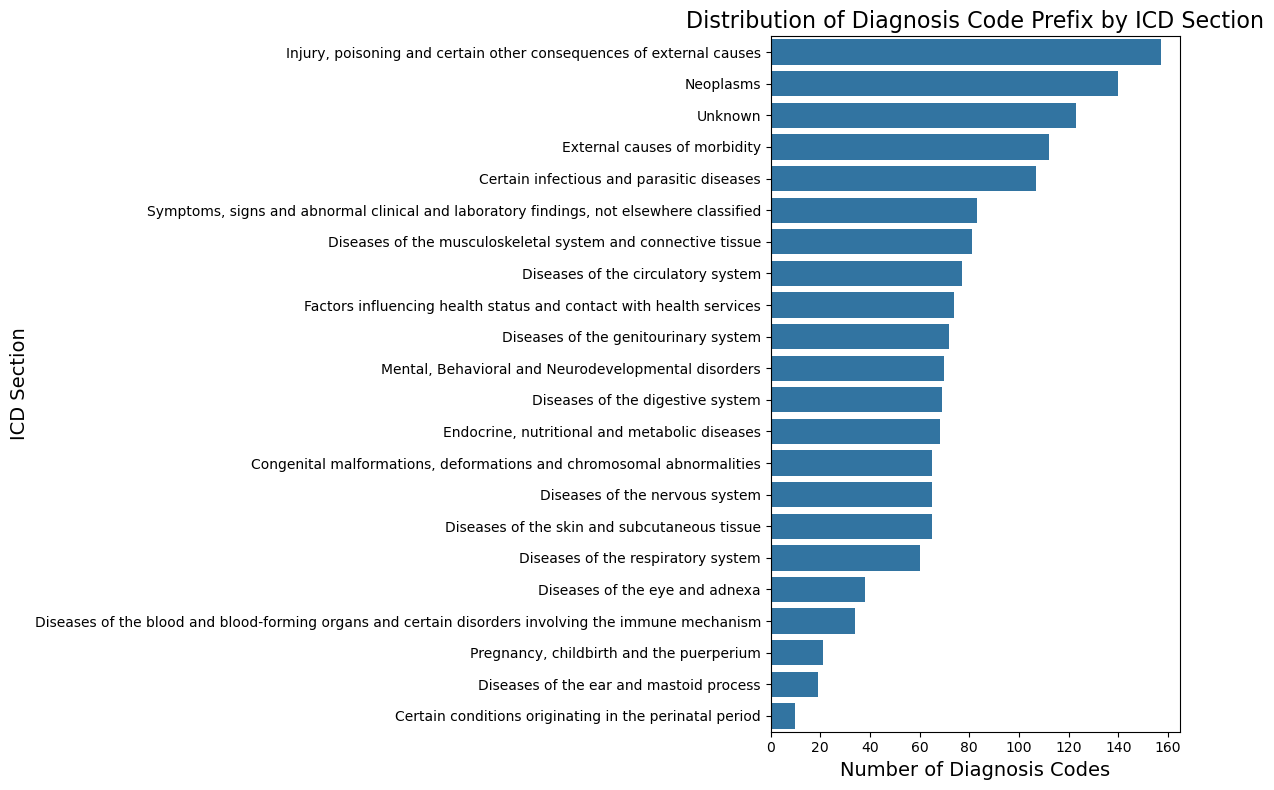

In [27]:
section_counts = grouped_stats.groupby('ICD_SECTION')['Diagnosis_Code_Prefix'].count().reset_index()
section_counts = section_counts.sort_values(by='Diagnosis_Code_Prefix', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Diagnosis_Code_Prefix', y='ICD_SECTION', data=section_counts)

plt.title('Distribution of Diagnosis Code Prefix by ICD Section', fontsize=16)
plt.xlabel('Number of Diagnosis Codes', fontsize=14)
plt.ylabel('ICD Section', fontsize=14)
plt.tight_layout()
plt.savefig('figures/distributionICDPrefixSection.png', format='png', dpi=300, bbox_inches='tight')
plt.show()